In [11]:
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
from model import FashionModel
from dataset import test_loader

model = FashionModel()
model.load_state_dict(torch.load('fashion_model_weights.pth', map_location = torch.device('cpu'), weights_only = True)) # load trained weights saved from Colab noebook

model.eval()

FashionModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
correct = 0
total = 0

with torch.no_grad(): # turns off automatic deifferentiation to save memory/compute
    # loop once through the entire test set to evaluate accuracy
    for images, labels in test_loader:
        outputs = model(images)
        top_guesses = torch.max(outputs, dim = 1)[1]
        total += labels.size(0)
        correct += (top_guesses == labels).sum().item()

final_accuracy = 100 * correct / total
print(f"accuracy on test set: {final_accuracy}%")

accuracy on test set: 90.53%


Now we will use a confusion matrix to visualize some aspects of the model's performance.
The entry $a_{ij}$ of the confusion matrix is the number of times an image from the $i^\text{th}$ class is predicted as the $j^\text{th}$ class.
Thus, scores on the diagonal indicate correct predictions, whereas scores off the diagonal indicate incorrect predictions.

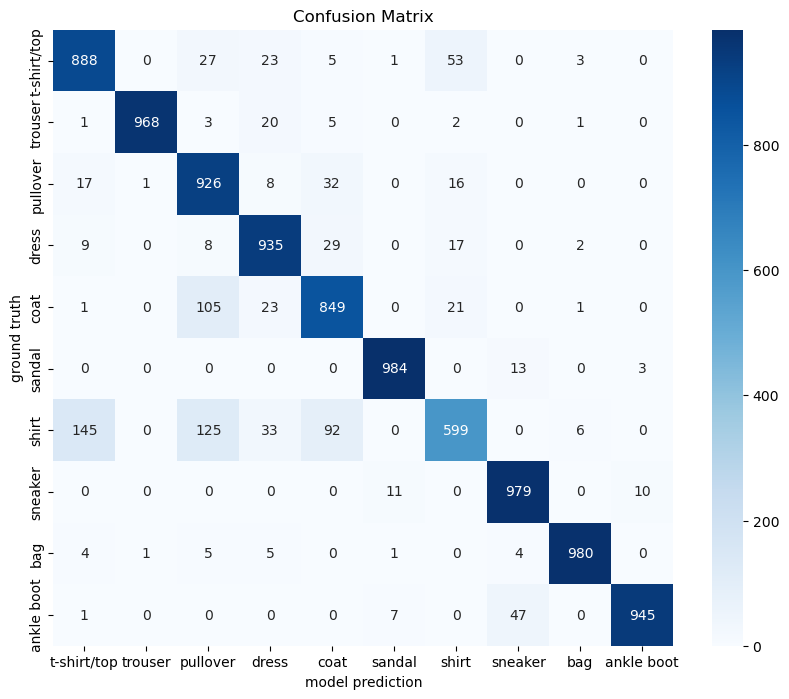

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes = {0: 't-shirt/top', 1: 'trouser', 2: 'pullover', 3: 'dress', 4: 'coat', 5: 'sandal', 6: 'shirt', 7: 'sneaker', 8: 'bag', 9: 'ankle boot'}

all_preds = []
all_labels = []

# get all the predictions and append them all together
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.max(outputs, dim = 1)[1]
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds) # calculate confusion matrix

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot=True, fmt = 'd', cmap ='Blues', xticklabels = classes.values(), yticklabels = classes.values())
plt.xlabel('model prediction')
plt.ylabel('ground truth')
plt.title('Confusion Matrix')
plt.show()



Notice that the off-diagonal entries with the highest scores correspond to reasonable mistakes. E.g., the confusion between shirts and t-shirts/tops (145 incorrect predictions) is reasonable since the general shape of shirts is quite similar to that of a t-shirt/top.